In [1]:
import scanpy as sc
import scvelo as scv
import anndata as ad
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

import pandas as pd
import numpy as np
import pickle
from sklearn import preprocessing
import json
import torch
from torch import nn
from torch.autograd.functional import jacobian
import os
from torchdiffeq import odeint
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, linregress
from sklearn.metrics.pairwise import cosine_similarity

import dynamo as dyn
dyn.dynamo_logger.main_silence()
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=14)
plt.rcParams['axes.grid'] = False
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [2]:
def arrowed_spines(ax, columns, background="white"):
    """
    画左下角箭头的函数，引自dynamo
    """
    if type(columns) == str:
        columns = [columns.upper() + " 1", columns.upper() + " 2"]
    import matplotlib.pyplot as plt

    fig = plt.gcf()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # removing the default axis on all sides:
    despline_all(ax)

    # removing the axis ticks
    deaxis_all(ax)

    # get width and height of axes object to compute
    # matching arrowhead length and width
    dps = fig.dpi_scale_trans.inverted()
    bbox = ax.get_window_extent().transformed(dps)
    width, height = bbox.width, bbox.height

    # manual arrowhead width and length (x-axis)
    hw = 1.0 / 20.0 * (ymax - ymin)
    hl = 1.0 / 20.0 * (xmax - xmin)
    lw = 1.0  # axis line width
    ohg = 0.2  # arrow overhang

    # compute matching arrowhead length and width (y-axis)
    yhw = hw / (ymax - ymin) * (xmax - xmin) * height / width
    yhl = hl / (xmax - xmin) * (ymax - ymin) * width / height

    # draw x and y axis
    fc, ec = ("w", "w") if background in ["black", "#ffffff"] else ("k", "k")
    ax.arrow(
        xmin,
        ymin,
        hl * 5 / 2,
        0,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=hw / 2,
        head_length=hl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )
    ax.arrow(
        xmin,
        ymin,
        0,
        hw * 5 / 2,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=yhw / 2,
        head_length=yhl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )

    ax.text(
        xmin + hl * 2.5 / 2,
        ymin - 1.5 * hw / 2,
        columns[0],
        ha="center",
        va="center",
        rotation=0,
        # size=hl * 5 / (2 * len(str(columns[0]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )
    ax.text(
        xmin - 1.5 * yhw / 2,
        ymin + hw * 2.5 / 2,
        columns[1],
        ha="center",
        va="center",
        rotation=90,
        # size=hw * 5 / (2 * len(str(columns[1]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )

    return ax

def despline_all(ax=None, sides=None):
    # removing the default axis on all sides:
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    if sides is None:
        sides = ["bottom", "right", "top", "left"]
    for side in sides:
        ax.spines[side].set_visible(False)


def deaxis_all(ax=None):
    # removing the axis ticks
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [3]:
## 真实向量场
def F(point, sets = np.array([10, 10*1e-3, 2, 0.5])):
    alfa, alfa0, n, beta = sets
    p1, p2, p3, m1, m2, m3 = point

    dp1 = -beta * (p1 - m1)
    dp2 = -beta * (p2 - m2)
    dp3 = -beta * (p3 - m3)
    
    dm1 = -m1 + alfa / (1 + p3 ** n) + alfa0
    dm2 = -m2 + alfa / (1 + p1 ** n) + alfa0
    dm3 = -m3 + alfa / (1 + p2 ** n) + alfa0

    return np.array([dp1, dp2, dp3, dm1, dm2, dm3])

In [4]:
def jacobian_F(point, sets=np.array([10, 10*1e-3, 2, 0.5])):
    alfa, alfa0, n, beta = sets
    p1, p2, p3, m1, m2, m3 = point
    J = np.zeros((6, 6))

    J[0, 0] = -beta      # dp1/dp1
    J[0, 3] = beta      # dp1/dm1
    J[1, 1] = -beta      # dp2/dp2
    J[1, 4] = beta      # dp2/dm2
    J[2, 2] = -beta      # dp3/dp3
    J[2, 5] = beta      # dp3/dm3
    J[3, 2] = -alfa * n * p3 ** (n - 1) / (1 + p3 ** n) ** 2  # dm1/dp3
    J[3, 3] = -1         # dm1/dm1
    J[4, 0] = -alfa * n * p1 ** (n - 1) / (1 + p1 ** n) ** 2  # dm2/dp1
    J[4, 4] = -1         # dm2/dm2
    J[5, 1] = -alfa * n * p2 ** (n - 1) / (1 + p2 ** n) ** 2  # dm3/dp2
    J[5, 5] = -1         # dm3/dm3

    return J

In [5]:
## VAE_NODE
class Encoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 5,
        n_hidden: int = 6,
        batch_norm: bool = False,
    ):
        super().__init__()

        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_int, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2_mean = nn.Linear(n_hidden, n_latent)
        self.fc2_logvar = nn.Linear(n_hidden, n_latent)

    def forward(self, x: torch.Tensor):
        x = self.fc1(x)
        mean = self.fc2_mean(x)
        logvar = self.fc2_logvar(x)
        return mean, logvar

class Decoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 5,
        n_hidden: int = 6,
        batch_norm: bool = False,
    ):
        super().__init__()
        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_latent, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        # self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2 = nn.Linear(n_hidden, n_int)

    def forward(self, z: torch.Tensor):
        z = self.fc1(z)
        recon_x = self.fc2(z)
        return recon_x

class LatentODE(nn.Module):
    def __init__(
        self,
        n_latent: int = 5,
        n_hidden: int = 32,
    ):
        super(LatentODE, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(in_features=n_latent, out_features=n_hidden, bias=True),
            nn.ELU())

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_hidden, bias=True),
            nn.BatchNorm1d(n_hidden),
            nn.ELU())

        self.layer4 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_latent, bias=True)
            )

    def forward(self, t, x):
        fc1 = self.layer1(x)
        fc2 = self.layer2(fc1)
        output = self.layer4(fc2)
        # return 0.144507 * output
        return 0.147265 * output

In [6]:
## NODE
class FullyConnected(nn.Module):
    def __init__(self):
        super(FullyConnected, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(in_features=6, out_features=32, bias=True),
            nn.ELU())

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=32, out_features=32, bias=True),
            nn.BatchNorm1d(32),
            nn.ELU())

        self.layer4 = nn.Sequential(
            nn.Linear(in_features=32, out_features=6, bias=True)
            )

    def forward(self, t, x):
        fc1 = self.layer1(x)
        fc2 = self.layer2(fc1)
        output = self.layer4(fc2)
        return 0.149676 * output

In [7]:
## 加载训练好的模型
encoder = Encoder(n_int=6)
decoder = Decoder(n_int=6)
dynamics_learner = LatentODE()
dynamics_learner.load_state_dict(torch.load('Parameters_dynamics.pickle', map_location=torch.device('cpu')))
encoder.load_state_dict(torch.load('Parameters_encoder.pickle', map_location=torch.device('cpu')))
decoder.load_state_dict(torch.load('Parameters_decoder.pickle', map_location=torch.device('cpu')))
dynamics_learner.eval()
encoder.eval()
decoder.eval()

NODE = FullyConnected()
NODE.load_state_dict(torch.load('Parameters_saved1_5.pickle', map_location=torch.device('cpu')))
NODE.eval()

FullyConnected(
  (layer1): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ELU(alpha=1.0)
  )
  (layer2): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
  )
  (layer4): Sequential(
    (0): Linear(in_features=32, out_features=6, bias=True)
  )
)

In [8]:
## 提取Decoder的参数
fc1_weight = decoder.fc1.L1.weight.data
fc1_bias = decoder.fc1.L1.bias.data
fc2_weight = decoder.fc2.weight.data
fc2_bias = decoder.fc2.bias.data

## Decoder的雅可比矩阵
weight = torch.matmul(fc2_weight, fc1_weight).numpy()
bias = (torch.matmul(fc2_weight, fc1_bias) + fc2_bias).numpy()

In [9]:
## 读取数据
with open('data_with_phase.pickle', 'rb') as f:
    adata = pickle.load(f)
adata.shape

(5000, 7)

In [10]:
## 归一化细胞数据
np_data = adata[:, :-1]

# for i in range(np_data.shape[1]):
#     gene_data = np_data[:, i]
#     gene_data -= gene_data.min()
#     gene_data /= gene_data.max()
#     np_data[:, i] = gene_data
np_data.shape

(5000, 6)

In [11]:
th=adata[:,-1]
minima = min(th)
maxima = max(th)
norm = matplotlib.colors.Normalize(vmin=minima, vmax=maxima)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.viridis)

In [12]:
## 定义vf_func及jac_func等函数
def F_without_t(x):
    return dynamics_learner(0, x)

def F_node_without_t(x):
    return NODE(0, x)
    
def vf_func(point: np.ndarray) -> np.ndarray:
    dim = point.shape[1]
    point = torch.as_tensor(point.reshape(-1, dim), dtype=torch.float32)
    f = F_without_t(point)
    return f.detach().numpy()

def jac_func_dyn(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((dim, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(F_without_t, x1).squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

def jac_func_encoder(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((5, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(encoder, x1)[0].squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

def jac_func_decoder(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((6, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(decoder, x1).squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

def jac_func_node(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((dim, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(F_node_without_t, x1).squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

In [13]:
## 计算重构及潜表示
raw = torch.as_tensor(np_data, dtype=torch.float32)
latent, _ = encoder(raw)
latent_std = torch.exp(0.5 * encoder(raw)[1])
reconstruct = decoder(latent)

raw = raw.detach().numpy()
reconstruct = reconstruct.detach().numpy()
latent = latent.detach().numpy()
latent_std = latent_std.detach().numpy()

# 计算VAE-NODE的velocity、jacobian、极限环

In [14]:
## 计算VAE-NODE的velocity及jacobian
velocity_latent = vf_func(latent)
jac_dyn = jac_func_dyn(latent)
jac_enc = jac_func_encoder(raw)
jac_dec = jac_func_decoder(latent)

In [15]:
## 对隐空间坐标位移一个V的单位并重构
latent_plus = latent + velocity_latent
latent_plus = torch.as_tensor(latent_plus, dtype=torch.float32)
reconstruct_plus = decoder(latent_plus)
reconstruct_plus = reconstruct_plus.detach().numpy()
velocity_reconstruct2 = reconstruct_plus - reconstruct ## 重构的velocity

velocity_reconstruct = velocity_latent @ (weight.T) ## 等价算法，会有数值误差

In [16]:
## 雅可比矩阵推断
n = latent.shape[0] # 细胞个数
jacobians_latent = np.zeros_like(jac_enc)
jacobians_VAE = np.zeros((6, 6, n)) # F的雅可比矩阵
for i in range(n):
    jac1 = jac_dyn[:,:,i]
    jac2 = jac_enc[:,:,i]
    jac3 = weight
    jac_latent = jac1 @ jac2 # 隐变量F对基因的雅可比
    jac = jac3 @ jac_latent # 重构F对基因的雅可比
    jacobians_VAE[:, :, i] = jac
    jacobians_latent[:, :, i] = jac_latent

In [17]:
# set initial points
x0 = np_data[0,:].reshape(-1,6)

# the length of sequence we predict
NK = 5000

t = torch.arange(0, 0.05 * NK, 0.05)

xx_VAE = np.zeros((6, NK))

x1 = torch.as_tensor(x0, dtype=torch.float32)
encoded, _ = encoder(x1)

latent_t = odeint(dynamics_learner, encoded, t, method='rk4')
latent_t = latent_t.permute(1, 2, 0).squeeze() # ode的解

for i in range(NK):
    encoded = latent_t[:, i]
    x0 = decoder(encoded)
    x0 = x0.detach().numpy()
    xx_VAE[:, i] = x0
    
latent_t = latent_t.detach().numpy()

# 计算NODE的velocity、jacobian、极限环

In [18]:
## 计算NODE的velocity及jacobian
velocity_node = np.zeros_like(np_data)
for i in range(velocity_node.shape[0]):
    x0 = np_data[i, :].reshape(1,-1)
    x1 = torch.as_tensor(x0, dtype=torch.float32)
    f = NODE(0, x1)
    v = f.detach().numpy()
    velocity_node[i, :] = np.squeeze(v)

jacobians_node = jac_func_node(np_data)

In [19]:
## 获得稳态解
# set initial points
x0 = np_data[0,:].reshape(-1,6)

# the length of sequence we predict
NK = 5000

x1 = torch.as_tensor(x0, dtype=torch.float32)
t = torch.arange(0, (NK+1) * 0.05, 0.05) #周期大约是1675
solution = odeint(NODE, x1, t, method='rk4')
solution = solution.squeeze().permute(1, 0)
xx_node = solution.detach().numpy()

# 计算GT的velocity、jacobian、极限环

In [20]:
## 计算真实velocity
velocity_true = np.zeros_like(np_data)
for i in range(velocity_true.shape[0]):
    x0 = np_data[i, :]
    v = F(x0)
    velocity_true[i, :] = v

In [21]:
## 计算真实雅可比矩阵
jacobians_true = np.zeros_like(jacobians_node)
for i in range(jacobians_true.shape[-1]):
    x0 = np_data[i, :]
    J = jacobian_F(x0)
    jacobians_true[:, :, i] = J

In [22]:
## 获得真实稳态解
initials = np_data[0,:]

step = 20000

P = initials
xx_true = np.zeros((6, step)) 
for i in range(step):
    xx_true[:, i] = P
    P = P + F(P) * 0.005 

# 比较三种方法的结果

In [23]:
## PCA降维
pca = PCA(n_components=2)
pca.fit(np_data)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
np_data_pca = (np_data - np.mean(np_data, axis=0)) @ V

# 得到速率投影
v_reconstruct_pca = velocity_reconstruct @ V
v_reconstruct_norm = (v_reconstruct_pca.T/np.linalg.norm(v_reconstruct_pca, axis=1)).T
v_true_pca = velocity_true @ V
v_true_norm = (v_true_pca.T/np.linalg.norm(v_true_pca, axis=1)).T
v_node_pca = velocity_node @ V
v_node_norm = (v_node_pca.T/np.linalg.norm(v_node_pca, axis=1)).T

In [24]:
## 创建adata数据
adata_GT = ad.AnnData(np_data, 
                          obsm={'X_z': np_data},
                          layers = {'spliced': np_data,
                                   'spliced_velocity': velocity_true},
                          )

adata_GT.obs['theta'] = adata[:, -1]
adata_GT.obsm['X_pca'] = np_data_pca
adata_GT.obsm['velocity_pca'] = v_true_pca
adata_GT.obsm['X_2dim'] = np_data[:,[0,1]]
adata_GT.obsm['velocity_2dim'] = velocity_true[:,[0,1]]
adata_GT.uns["velocity_params"] = {'embeddings':['pca','2dim']}


adata_node = ad.AnnData(np_data, 
                          obsm={'X_z': np_data},
                          layers = {'spliced': np_data,
                                   'spliced_velocity': velocity_node},
                          )

adata_node.obs['theta'] = adata[:, -1]
adata_node.obsm['X_pca'] = np_data_pca
adata_node.obsm['velocity_pca'] = v_node_pca
adata_node.obsm['X_2dim'] = np_data[:,[0,1]]
adata_node.obsm['velocity_2dim'] = velocity_node[:,[0,1]]
adata_node.uns["velocity_params"] = {'embeddings':['pca','2dim']}


adata_vae_node = ad.AnnData(np_data, 
                          obsm={'X_z': np_data},
                          layers = {'spliced': np_data,
                                   'spliced_velocity': velocity_reconstruct},
                          )

adata_vae_node.obs['theta'] = adata[:, -1]
adata_vae_node.obsm['X_pca'] = np_data_pca
adata_vae_node.obsm['velocity_pca'] = v_reconstruct_pca
adata_vae_node.obsm['X_2dim'] = np_data[:,[0,1]]
adata_vae_node.obsm['velocity_2dim'] = velocity_reconstruct[:,[0,1]]
adata_vae_node.uns["velocity_params"] = {'embeddings':['pca','2dim']}

Text(0.5, 1.0, 'velocity_true')

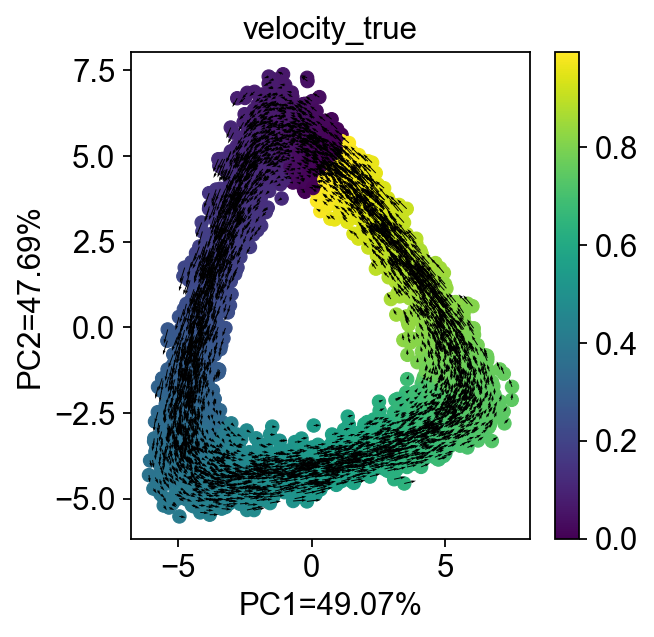

In [25]:
plt.scatter(np_data_pca[:, 0], np_data_pca[:, 1],c=th,cmap=cm.viridis)
plt.quiver(np_data_pca[:, 0], np_data_pca[:, 1], v_true_pca[:, 0], v_true_pca[:, 1],scale=7, scale_units='xy')
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(f'PC1={ratio[0] * 100:.2f}%')
plt.ylabel(f'PC2={ratio[1] * 100:.2f}%')
plt.title('velocity_true')
# plt.savefig('1.png', dpi=300)

Text(0.5, 1.0, 'velocity_VAE_nODE')

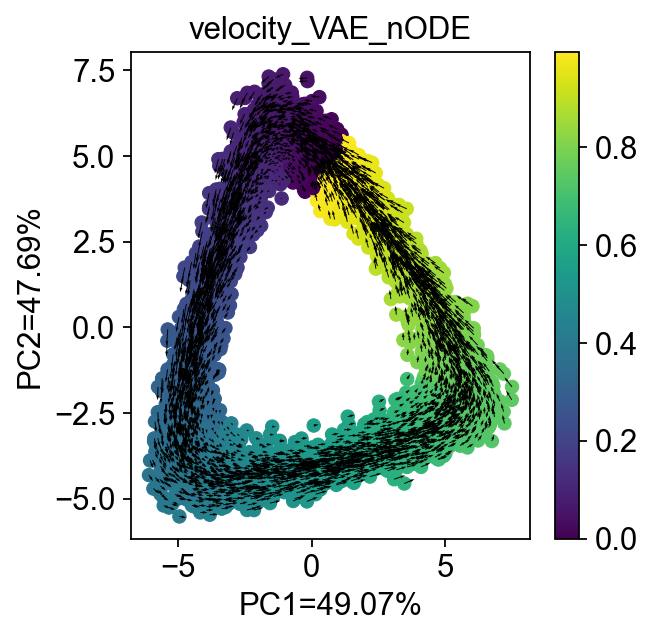

In [26]:
plt.scatter(np_data_pca[:, 0], np_data_pca[:, 1],c=th,cmap=cm.viridis)
plt.quiver(np_data_pca[:, 0], np_data_pca[:, 1], v_reconstruct_pca[:, 0], v_reconstruct_pca[:, 1],scale=7, scale_units='xy')
# plt.plot(xx_pca[0, 2000:], xx_pca[1, 2000:], linewidth=2.0, color='red', alpha=0.9)
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(f'PC1={ratio[0] * 100:.2f}%')
plt.ylabel(f'PC2={ratio[1] * 100:.2f}%')
plt.title('velocity_VAE_nODE')
# plt.savefig('1.png', dpi=300)

Text(0.5, 1.0, 'velocity_nODE')

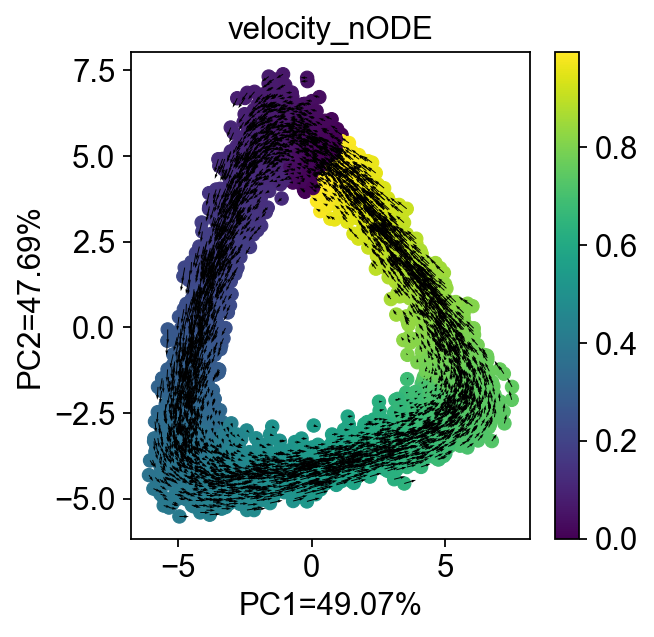

In [27]:
plt.scatter(np_data_pca[:, 0], np_data_pca[:, 1],c=th,cmap=cm.viridis)
plt.quiver(np_data_pca[:, 0], np_data_pca[:, 1], v_node_pca[:, 0], v_node_pca[:, 1],scale=7, scale_units='xy')
# plt.plot(xx_pca[0, 2000:], xx_pca[1, 2000:], linewidth=2.0, color='red', alpha=0.9)
plt.colorbar(mapper, ax=plt.gca())
plt.xlabel(f'PC1={ratio[0] * 100:.2f}%')
plt.ylabel(f'PC2={ratio[1] * 100:.2f}%')
plt.title('velocity_nODE')
# plt.savefig('1.png', dpi=300)

saving figure to file ../figures/streamplot_gt.svg


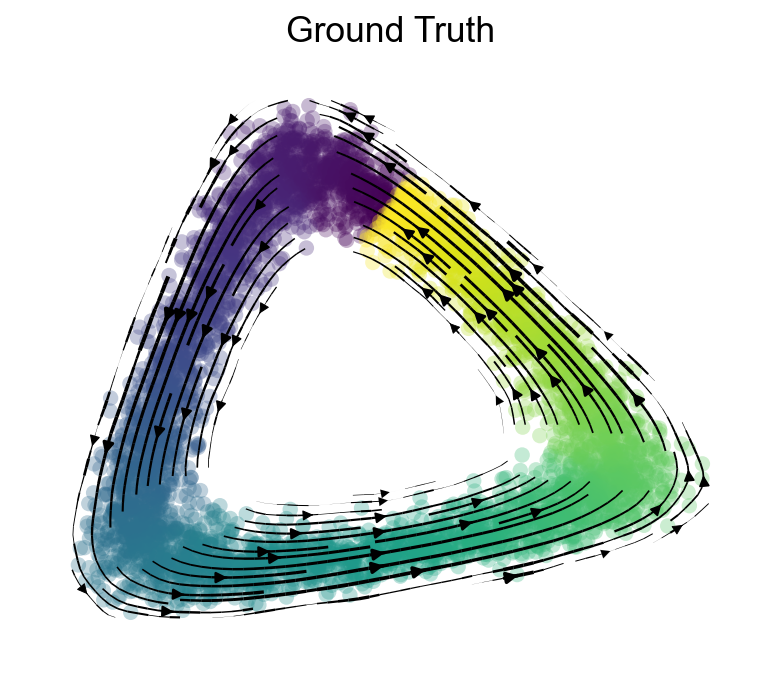

In [28]:
scv.pl.velocity_embedding_stream(
    adata_GT, 
    density=2, smooth=0.5, min_mass=1,
    basis='pca', 
    color='theta', 
    title="Ground Truth",
    fontsize=16,
    color_map='viridis',
    colorbar=False,
    figsize=(6,5),add_margin=0.1,rasterized=True,
    save='../figures/streamplot_gt.svg'
)

saving figure to file ../figures/streamplot_node.svg


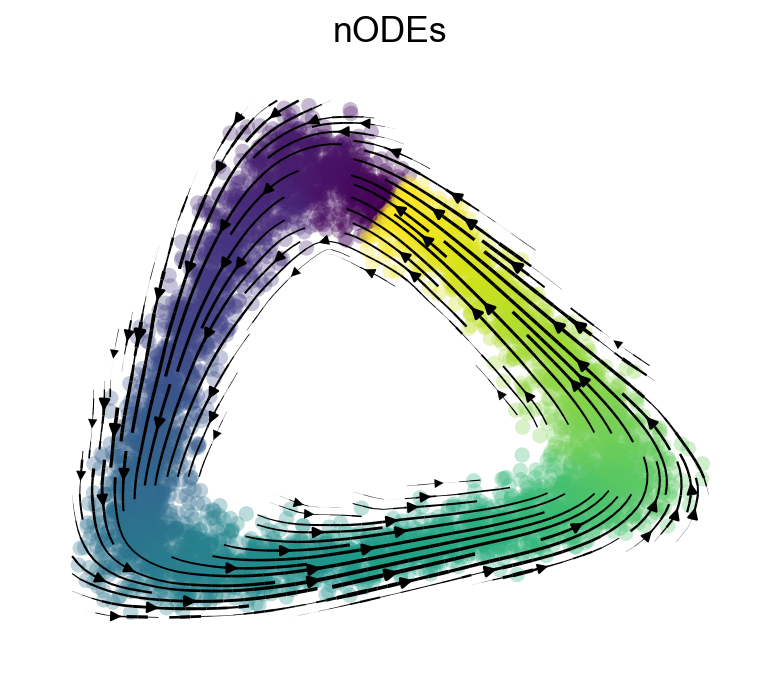

In [29]:
scv.pl.velocity_embedding_stream(
    adata_node, 
    density=2, smooth=0.5, min_mass=1,
    basis='pca', 
    color='theta', 
    title="nODEs",
    fontsize=16,
    color_map='viridis',
    colorbar=False,
    figsize=(6,5),add_margin=0.1,rasterized=True,
    save='../figures/streamplot_node.svg'
)

saving figure to file ../figures/streamplot_vae_node.svg


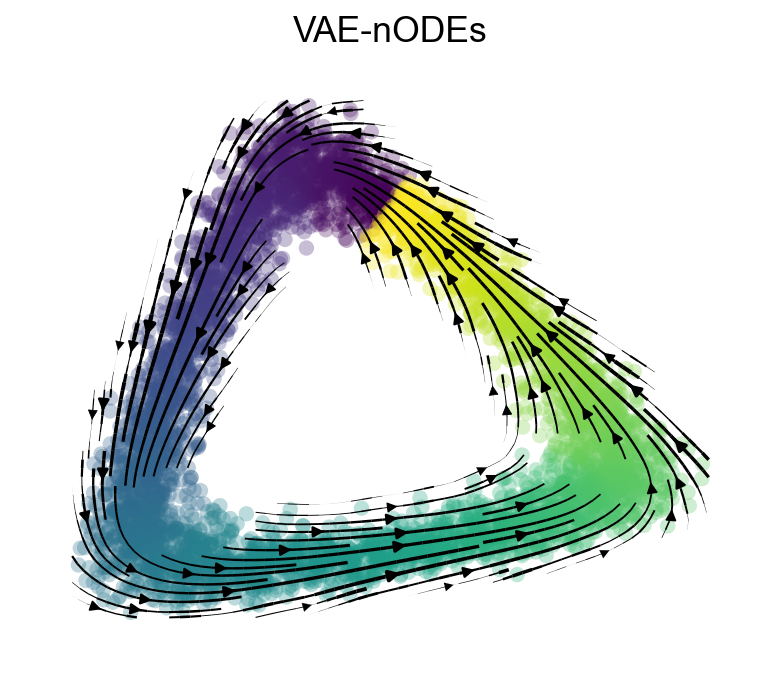

In [30]:
scv.pl.velocity_embedding_stream(
    adata_vae_node, 
    density=2, smooth=0.5, min_mass=1,
    basis='pca', 
    color='theta', 
    title="VAE-nODEs",
    fontsize=16,
    color_map='viridis',
    colorbar=False,
    figsize=(6,5),add_margin=0.1,rasterized=True,
    save='../figures/streamplot_vae_node.svg'
)

Pearson correlation coefficient: 0.8885420681107947
P-value: 0.0


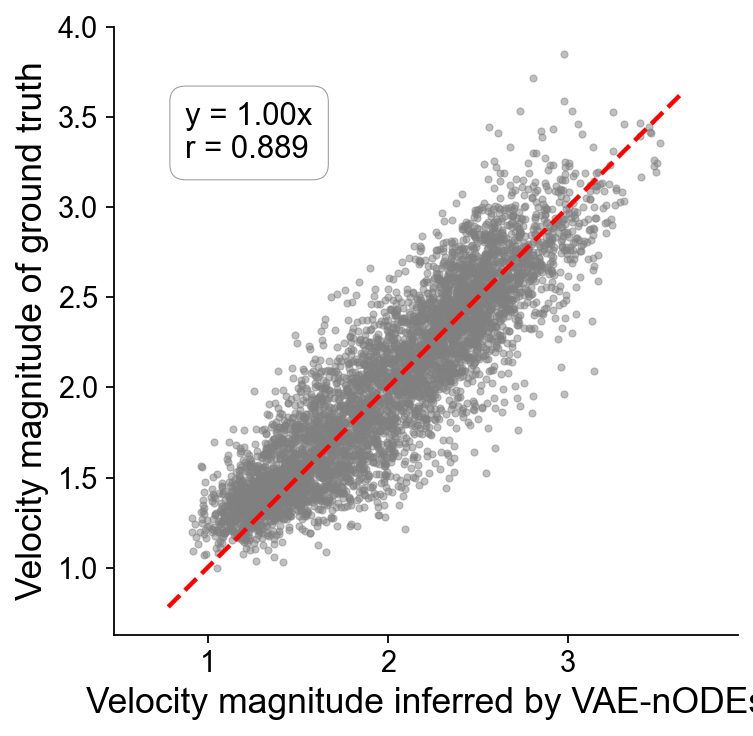

In [31]:
## 计算速度大小（范数）
norm1 = np.linalg.norm(velocity_reconstruct, axis=1)
norm2 = np.linalg.norm(velocity_node, axis=1)
norm3 = np.linalg.norm(velocity_true, axis=1)

# slope, intercept, r_value, p_value, std_err = linregress(norm1, norm2) # 线性回归
corr_coef, p_value = pearsonr(norm1, norm3)
print("Pearson correlation coefficient:", corr_coef)
print("P-value:", p_value)
slope = np.sum(norm1 * norm3) / np.sum(norm1**2)
plt.figure(figsize=(5, 5))
plt.scatter(norm1, norm3, c='gray', s=10, alpha=0.5, rasterized=True)
x_vals = np.array(plt.gca().get_xlim())
y_vals = slope * x_vals
plt.plot(x_vals, y_vals, '--', color='red', linewidth=2, label='Linear fit')

equation_text = f'y = {slope:.2f}x\nr = {corr_coef:.3f}'
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.75, edgecolor='gray')
plt.text(0.25 * norm1.max(), 0.85 * norm3.max(), equation_text, fontsize=14, bbox=props, family='Arial')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('Velocity magnitude inferred by VAE-nODEs', fontsize=16)
plt.ylabel('Velocity magnitude of ground truth', fontsize=16)
plt.axis('equal')
plt.savefig('../figures/Magnitude1.svg', bbox_inches='tight', transparent=True, dpi=300)

Pearson correlation coefficient: 0.8782727691193262
P-value: 0.0


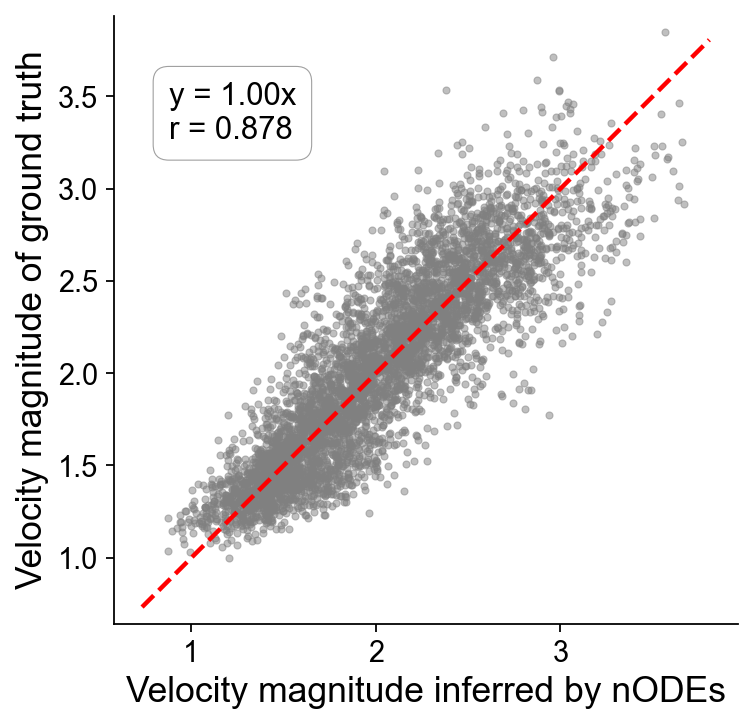

In [32]:
corr_coef, p_value = pearsonr(norm2, norm3)
print("Pearson correlation coefficient:", corr_coef)
print("P-value:", p_value)
slope = np.sum(norm2 * norm3) / np.sum(norm2**2)
plt.figure(figsize=(5, 5))
plt.scatter(norm2, norm3, c='gray', s=10, alpha=0.5, rasterized=True)
x_vals = np.array(plt.gca().get_xlim())
y_vals = slope * x_vals
plt.plot(x_vals, y_vals, '--', color='red', linewidth=2, label='Linear fit')

equation_text = f'y = {slope:.2f}x\nr = {corr_coef:.3f}'
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.75, edgecolor='gray')
plt.text(0.25 * norm1.max(), 0.85 * norm3.max(), equation_text, fontsize=14, bbox=props, family='Arial')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('Velocity magnitude inferred by nODEs', fontsize=16)
plt.ylabel('Velocity magnitude of ground truth', fontsize=16)
plt.axis('equal')
plt.savefig('../figures/Magnitude2.svg', bbox_inches='tight', transparent=True, dpi=300)

Pearson correlation coefficient: 0.8811485191674219
P-value: 0.0


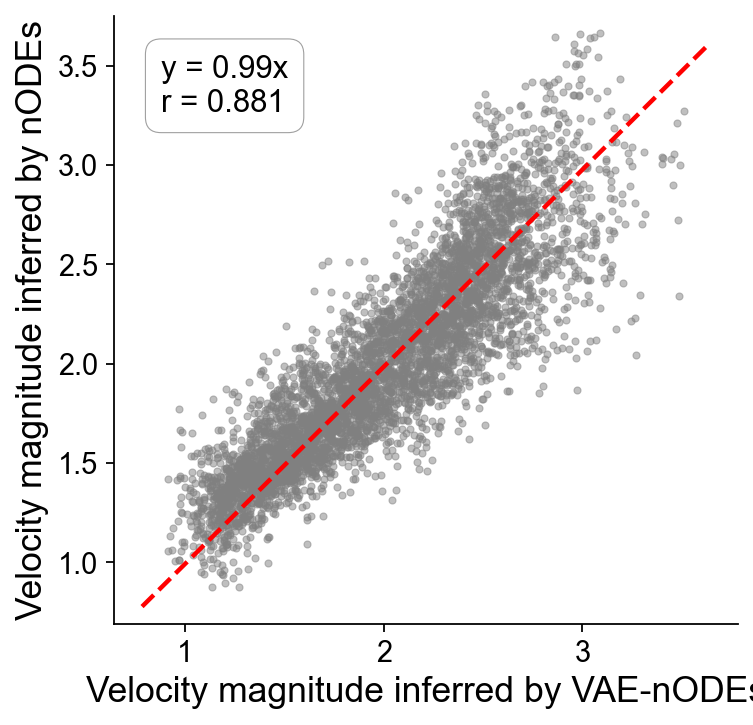

In [33]:
corr_coef, p_value = pearsonr(norm1, norm2)
print("Pearson correlation coefficient:", corr_coef)
print("P-value:", p_value)
slope = np.sum(norm1 * norm2) / np.sum(norm1**2)
plt.figure(figsize=(5, 5))
plt.scatter(norm1, norm2, c='gray', s=10, alpha=0.5, rasterized=True)
x_vals = np.array(plt.gca().get_xlim())
y_vals = slope * x_vals
plt.plot(x_vals, y_vals, '--', color='red', linewidth=2, label='Linear fit')

equation_text = f'y = {slope:.2f}x\nr = {corr_coef:.3f}'
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.75, edgecolor='gray')
plt.text(0.25 * norm1.max(), 0.85 * norm3.max(), equation_text, fontsize=14, bbox=props, family='Arial')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('Velocity magnitude inferred by VAE-nODEs', fontsize=16)
plt.ylabel('Velocity magnitude inferred by nODEs', fontsize=16)
plt.axis('equal')
plt.savefig('../figures/Magnitude3.svg', bbox_inches='tight', transparent=True, dpi=300)

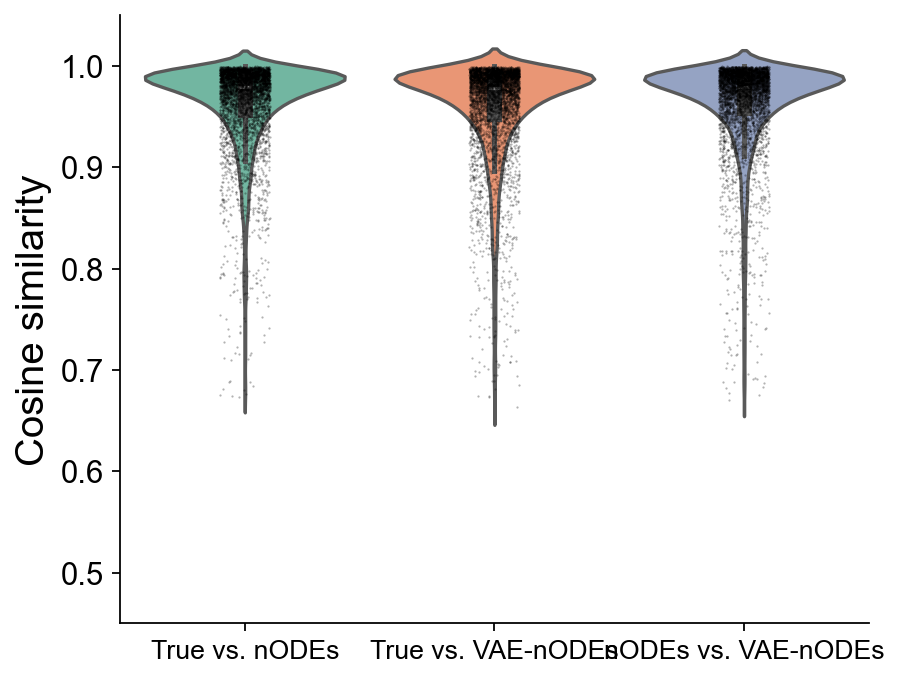

In [34]:
## 计算余弦相似度
cos_similarities1 = np.diag(cosine_similarity(velocity_node, velocity_true))
lower_percentile = np.percentile(cos_similarities1, 0.5)
cos_similarities1 = cos_similarities1[cos_similarities1 >= lower_percentile]
cos_similarities2 = np.diag(cosine_similarity(velocity_reconstruct, velocity_true))
lower_percentile = np.percentile(cos_similarities2, 0.5)
cos_similarities2 = cos_similarities2[cos_similarities2 >= lower_percentile]
cos_similarities3 = np.diag(cosine_similarity(velocity_reconstruct, velocity_node))
lower_percentile = np.percentile(cos_similarities3, 0.5)
cos_similarities3 = cos_similarities3[cos_similarities3 >= lower_percentile]

cos_similarities = np.concatenate([cos_similarities1, cos_similarities2, cos_similarities3])
labels = ['True vs. nODEs'] * len(cos_similarities1) + ['True vs. VAE-nODEs'] * len(cos_similarities2) + ['nODEs vs. VAE-nODEs'] * len(cos_similarities3)

plt.figure(figsize=(6, 5))
sns.violinplot(x=labels, y=cos_similarities, palette="Set2", linewidth=1.5, inner="box")

# 叠加散点
sns.stripplot(x=labels, y=cos_similarities, color='k', alpha=0.3, size=1, jitter=True, rasterized=True)

# 视觉优化
plt.ylim(0.45, 1.05)
# plt.title('Violin Plot of Velocity Cosine Similarities', fontsize=14, fontweight='bold')
plt.ylabel('Cosine similarity', fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../figures/violin.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

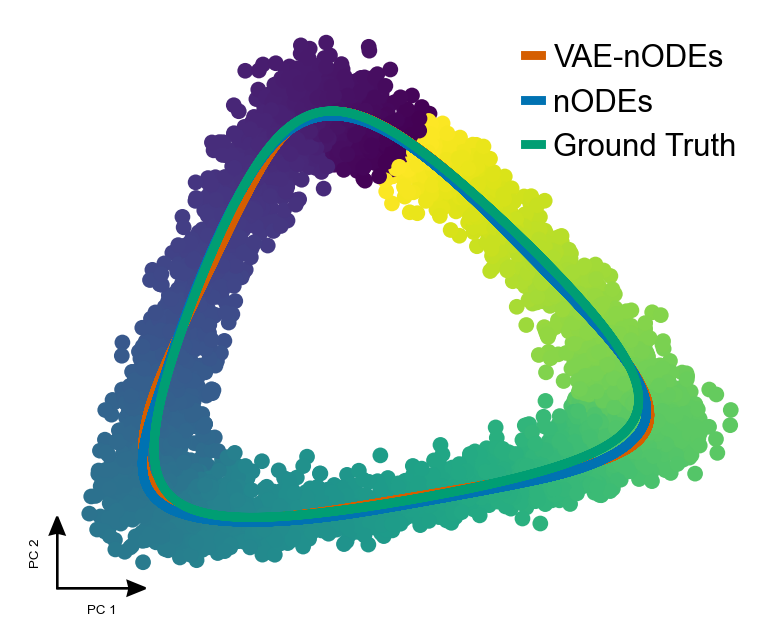

In [35]:
xx_VAE_pca = ((xx_VAE.T - np.mean(np_data, axis=0)) @ V).T
xx_node_pca = ((xx_node.T - np.mean(np_data, axis=0)) @ V).T
xx_true_pca = ((xx_true.T - np.mean(np_data, axis=0)) @ V).T

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(xx_VAE_pca[0, 2000:], xx_VAE_pca[1, 2000:], linewidth=4.0, color='#D55E00', label='VAE-nODEs')
ax.plot(xx_node_pca[0, 2000:], xx_node_pca[1, 2000:], linewidth=4.0, color='#0072B2', label='nODEs')
ax.plot(xx_true_pca[0, 10000:], xx_true_pca[1, 10000:], linewidth=4.0, color='#009E73', label='Ground Truth')

ax.scatter(np_data_pca[:, 0], np_data_pca[:, 1], c=th, cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)

arrowed_spines(ax, columns="PC")
ax.legend(loc='best', fontsize=14, frameon=False)

plt.savefig('../figures/limit_cycle_PC.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

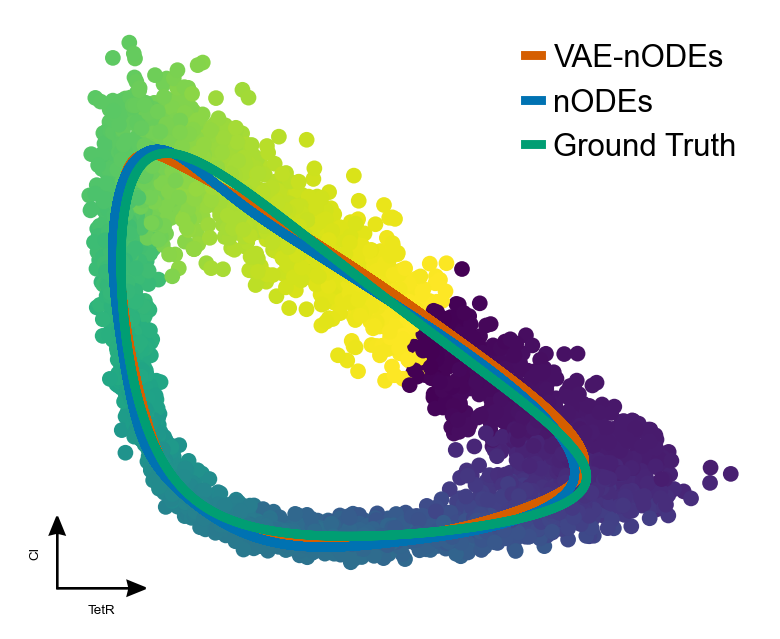

In [36]:
index1 = 1
index2 = 2
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(xx_VAE[index1, 2000:], xx_VAE[index2, 2000:], linewidth=4.0, color='#D55E00', label='VAE-nODEs')
ax.plot(xx_node[index1, 2000:], xx_node[index2, 2000:], linewidth=4.0, color='#0072B2', label='nODEs')
ax.plot(xx_true[index1, 10000:], xx_true[index2, 10000:], linewidth=4.0, color='#009E73', label='Ground Truth')

ax.scatter(np_data[:, index1], np_data[:, index2], c=th, cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)

arrowed_spines(ax, columns=['TetR','CI'])
ax.legend(loc='best', fontsize=14, frameon=False)

plt.savefig('../figures/limit_cycle_1.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

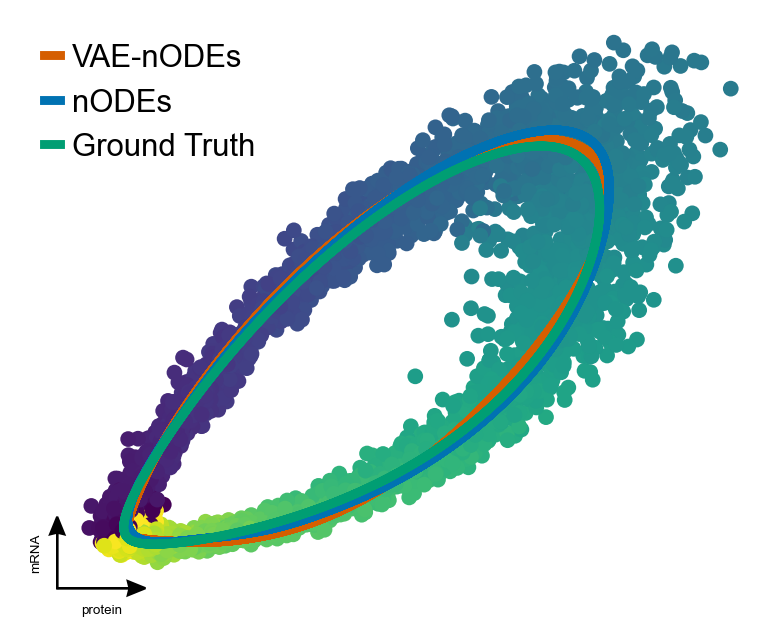

In [37]:
index1 = 0
index2 = 3
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(xx_VAE[index1, 2000:], xx_VAE[index2, 2000:], linewidth=4.0, color='#D55E00', label='VAE-nODEs')
ax.plot(xx_node[index1, 2000:], xx_node[index2, 2000:], linewidth=4.0, color='#0072B2', label='nODEs')
ax.plot(xx_true[index1, 10000:], xx_true[index2, 10000:], linewidth=4.0, color='#009E73', label='Ground Truth')

ax.scatter(np_data[:, index1], np_data[:, index2], c=th, cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)

arrowed_spines(ax, columns=['protein','mRNA'])
ax.legend(loc='best', fontsize=14, frameon=False)

plt.savefig('../figures/limit_cycle_2.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

In [38]:
## 考察平均的雅可比阵
jacobians_VAE_mean = np.mean(jacobians_VAE, axis=-1)
jacobians_true_mean = np.mean(jacobians_true, axis=-1)
jacobians_node_mean = np.mean(jacobians_node, axis=-1)

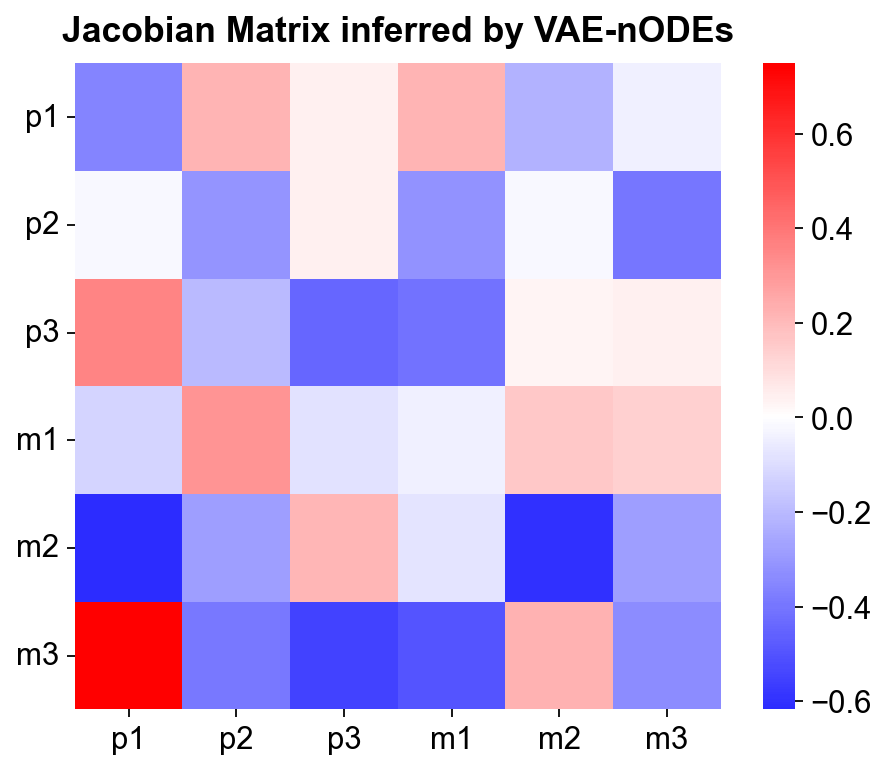

In [39]:
gene_names = ["p1", "p2", "p3", "m1", "m2", "m3"]

plt.figure(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["blue", "white", "red"])
ax = sns.heatmap(jacobians_VAE_mean, annot=False, fmt=".2f", cmap=cmap, cbar=True,
            square=True, center=0)  # 使用center=0确保0值为白色

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

ax.set_xticklabels(gene_names, fontsize=14, rotation=0)
ax.set_yticklabels(gene_names, fontsize=14, rotation=0)

plt.title('Jacobian Matrix inferred by VAE-nODEs', fontsize=16, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('../figures/jacobians_vae.svg', bbox_inches='tight', transparent=True)
plt.show()

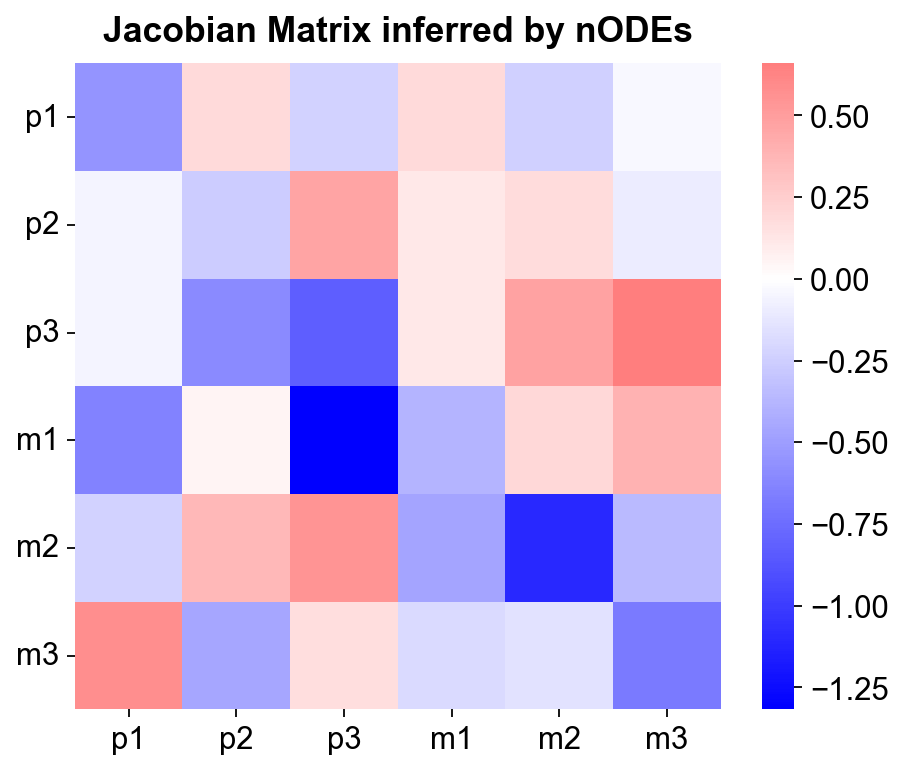

In [40]:
plt.figure(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["blue", "white", "red"])
ax = sns.heatmap(jacobians_node_mean, annot=False, fmt=".2f", cmap=cmap, cbar=True,
            square=True, center=0)  # 使用center=0确保0值为白色

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

ax.set_xticklabels(gene_names, fontsize=14, rotation=0)
ax.set_yticklabels(gene_names, fontsize=14, rotation=0)

plt.title('Jacobian Matrix inferred by nODEs', fontsize=16, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('../figures/jacobians_node.svg', bbox_inches='tight', transparent=True)
plt.show()

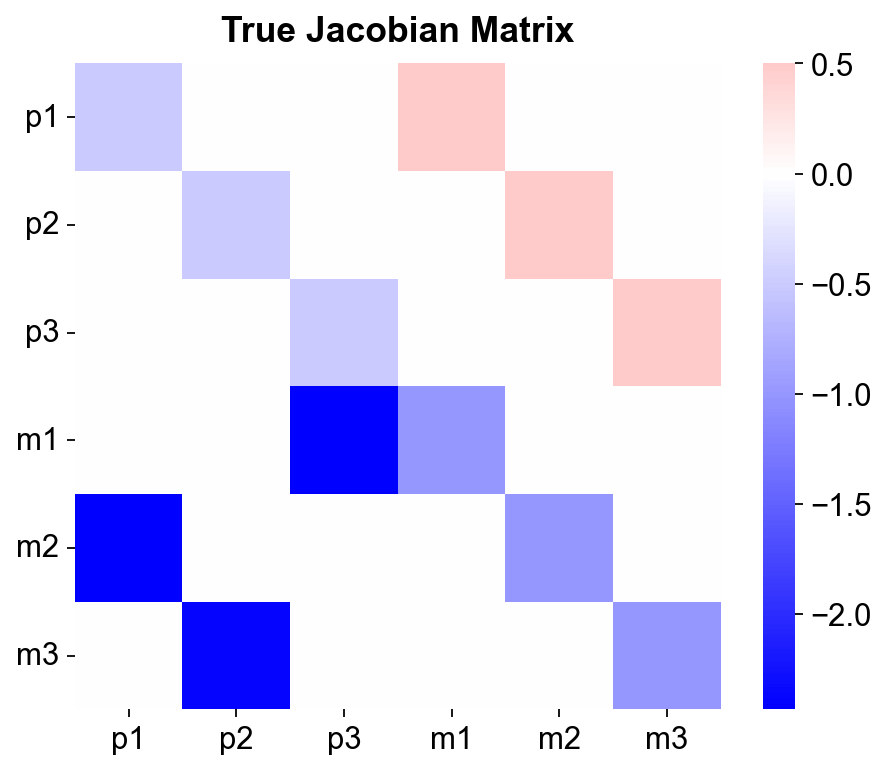

In [41]:
plt.figure(figsize=(6, 5))
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", ["blue", "white", "red"])
ax = sns.heatmap(jacobians_true_mean, annot=False, fmt=".2f", cmap=cmap, cbar=True,
            square=True, center=0)  # 使用center=0确保0值为白色

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

ax.set_xticklabels(gene_names, fontsize=14, rotation=0)
ax.set_yticklabels(gene_names, fontsize=14, rotation=0)

plt.title('True Jacobian Matrix', fontsize=16, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('../figures/jacobians_true.svg', bbox_inches='tight', transparent=True)
plt.show()